In [479]:
import pandas as pd
import numpy as np
import skfuzzy as fuzz
from collections import defaultdict
import matplotlib.pyplot as plt


In [480]:
df = pd.read_excel("./datasets/Specimens-Train.xlsx")

cols = ["TOTAL SPECIMENS", "TOTAL A", "TOTAL B"]
df = df[cols].dropna().reset_index(drop=True)

print(f"Data loaded. Total length: {len(df)}")


Data loaded. Total length: 238


In [481]:
split_ratio = 0.8
split_idx = int(split_ratio * len(df))


train_df = df.iloc[:split_idx].copy().reset_index(drop=True)
test_df  = df.iloc[split_idx:].copy().reset_index(drop=True)

print(f"Train: {len(train_df)} samples ({split_ratio*100:.0f}%)")
print(f"Test : {len(test_df)} samples ({(1-split_ratio)*100:.0f}%)")

Train: 190 samples (80%)
Test : 48 samples (20%)


In [ ]:
scaling_params = {} 

for col in train_df.columns:
    col_min = train_df[col].min()
    col_max = train_df[col].max()
    
    scaling_params[col] = (col_min, col_max)
    
    train_df[col] = (train_df[col] - col_min) / (col_max - col_min)
    
    test_df[col] = (test_df[col] - col_min) / (col_max - col_min)

print("\nNormalization applied (Min-Max 0-1 range).")

print("\nTrain min values after scaling:")
print(train_df.min())

print("\nTrain max values after scaling:")
print(train_df.max())


Normalization applied (Min-Max 0-1 range).

Train min values after scaling:
TOTAL SPECIMENS    0.0
TOTAL A            0.0
TOTAL B            0.0
dtype: float64

Train max values after scaling:
TOTAL SPECIMENS    1.0
TOTAL A            1.0
TOTAL B            1.0
dtype: float64


In [ ]:
def create_lagged(df, lag=1):
    X, Y = [], []
    for i in range(lag, len(df)):
        X.append(df.iloc[i-lag].values) 
        Y.append(df.iloc[i].values)       
    return np.array(X), np.array(Y)

X_train, Y_train = create_lagged(train_df, lag=1)
X_test,  Y_test  = create_lagged(test_df,  lag=1)

print("\nLagged dataset created:")
print("X_train shape:", X_train.shape)
print("Y_train shape:", Y_train.shape)
print("X_test  shape:", X_test.shape)
print("Y_test  shape:", Y_test.shape)


Lagged dataset created:
X_train shape: (189, 3)
Y_train shape: (189, 3)
X_test  shape: (47, 3)
Y_test  shape: (47, 3)


In [496]:
expansion_factor = 0.2

universes = {}

for col in train_df.columns:
    y_min = train_df[col].min()
    y_max = train_df[col].max()
    
    D = expansion_factor * (y_max - y_min)
    U_min = y_min - D
    U_max = y_max + D
    
    universes[col] = (U_min, U_max)
    
    print(f"{col}")
    print(f"  U_min: {U_min:.4f}   U_max: {U_max:.4f}")

TOTAL SPECIMENS
  U_min: -0.2000   U_max: 1.2000
TOTAL A
  U_min: -0.2000   U_max: 1.2000
TOTAL B
  U_min: -0.2000   U_max: 1.2000


In [507]:
c_selected = 2
print(f"Selected number of fuzzy sets per variable: {c_selected}\n")

fuzzy_centers = {}

for col in train_df.columns:
    
    values = train_df[col].values.reshape(1, -1)
    
    cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
        values,
        c=c_selected,
        m=2.0,
        error=0.005,
        maxiter=1000
    )
    
    centers_sorted = np.sort(cntr.flatten())
    fuzzy_centers[col] = centers_sorted
    
    print(f"{col} centers:")
    print(np.round(centers_sorted, 4))
    print()

Selected number of fuzzy sets per variable: 2

TOTAL SPECIMENS centers:
[0.1588 0.58  ]

TOTAL A centers:
[0.0369 0.6141]

TOTAL B centers:
[0.0199 0.6864]



In [ ]:
fuzzy_sets = {}  

for col in train_df.columns:
    
    centers = fuzzy_centers[col]
    U_min, U_max = universes[col]
    
    boundaries = [(centers[i] + centers[i+1]) / 2 for i in range(len(centers)-1)]

    intervals = [(U_min, boundaries[0])]
    for i in range(len(boundaries)-1):
        intervals.append((boundaries[i], boundaries[i+1]))
    intervals.append((boundaries[-1], U_max))

    sets = []
    for i in range(len(centers)):
        if i == 0:
            a, b, c = intervals[0][0], centers[0], centers[1]
        elif i == len(centers)-1:
            a, b, c = centers[-2], centers[-1], intervals[-1][1]
        else:
            a, b, c = centers[i-1], centers[i], centers[i+1]
        
        a, b, c = max(0.0, a), b, min(1.0, c)
        sets.append((a, b, c))
    
    fuzzy_sets[col] = sets

for col in fuzzy_sets:
    print(f"\n{col} fuzzy sets (normalized 0-1):")
    for i, (a,b,c) in enumerate(fuzzy_sets[col], 1):
        print(f"A{i}: {a:>6.3f} → {b:>6.3f} → {c:>6.3f}")



TOTAL SPECIMENS fuzzy sets (normalized 0-1):
A1:  0.000 →  0.159 →  0.580
A2:  0.159 →  0.580 →  1.000

TOTAL A fuzzy sets (normalized 0-1):
A1:  0.000 →  0.037 →  0.614
A2:  0.037 →  0.614 →  1.000

TOTAL B fuzzy sets (normalized 0-1):
A1:  0.000 →  0.020 →  0.686
A2:  0.020 →  0.686 →  1.000


In [ ]:
def triangular_mf(x, a, b, c):
    if x <= a or x >= c:
        return 0.0
    if x <= b:
        return (x - a) / (b - a) if b != a else 0.0
    return (c - x) / (c - b) if c != b else 0.0

def fuzzify_value(value, fuzzy_sets_var):
    memberships = [triangular_mf(value, *fs) for fs in fuzzy_sets_var]
    return np.argmax(memberships)


def fuzzify_vector(row):
    labels = []
    for i, col in enumerate(train_df.columns):
        fs = fuzzy_sets[col]
        labels.append(fuzzify_value(row[i], fs))
    return tuple(labels)


fuzzy_X_train = np.array([fuzzify_vector(x) for x in X_train])
fuzzy_Y_train = np.array([fuzzify_vector(y) for y in Y_train])

fuzzy_X_test  = np.array([fuzzify_vector(x) for x in X_test])
fuzzy_Y_test  = np.array([fuzzify_vector(y) for y in Y_test])

print("Fuzzy X_train sample:")
print(fuzzy_X_train[:5])

print("\nFuzzy Y_train sample:")
print(fuzzy_Y_train[:5])


Fuzzy X_train sample:
[[0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]]

Fuzzy Y_train sample:
[[0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]]


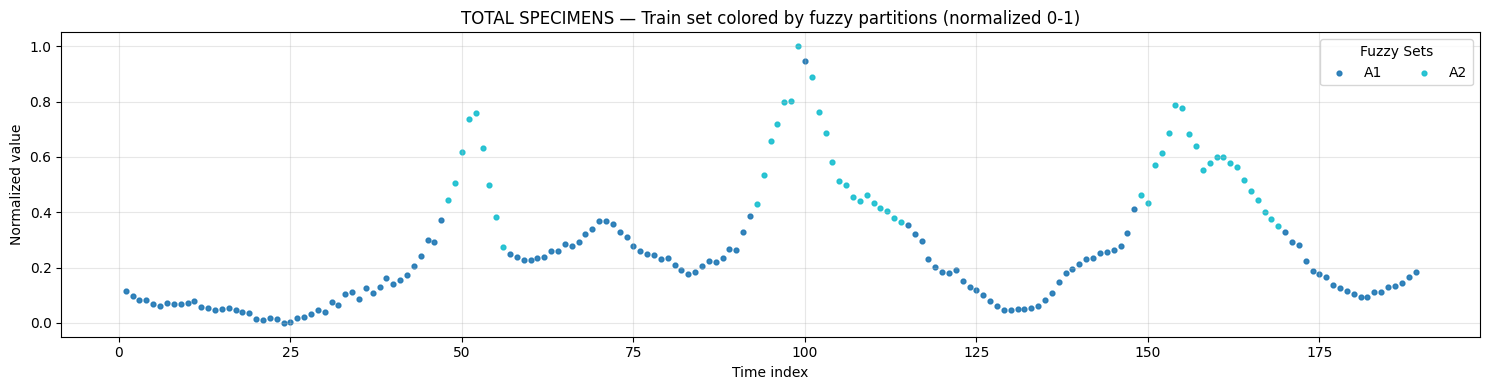

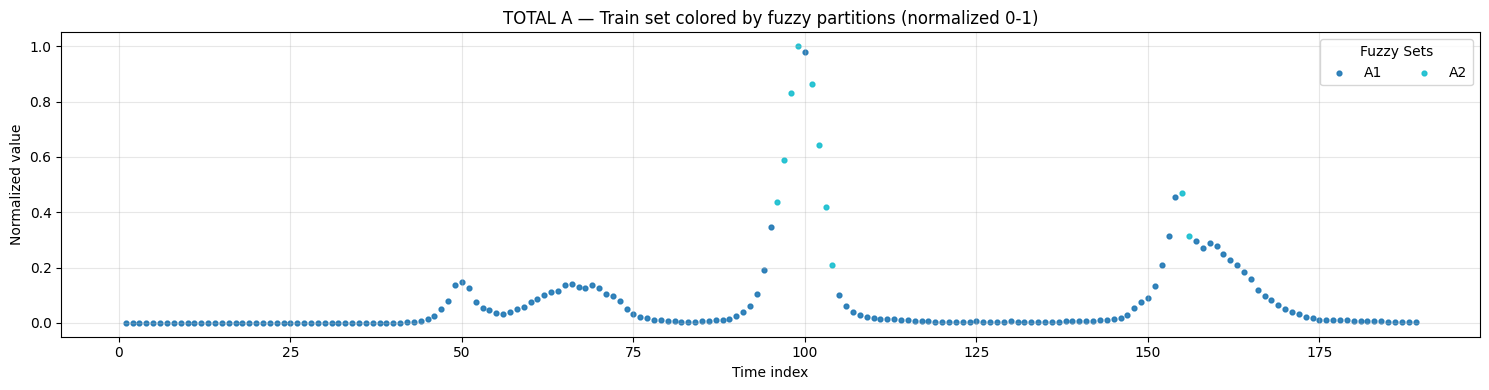

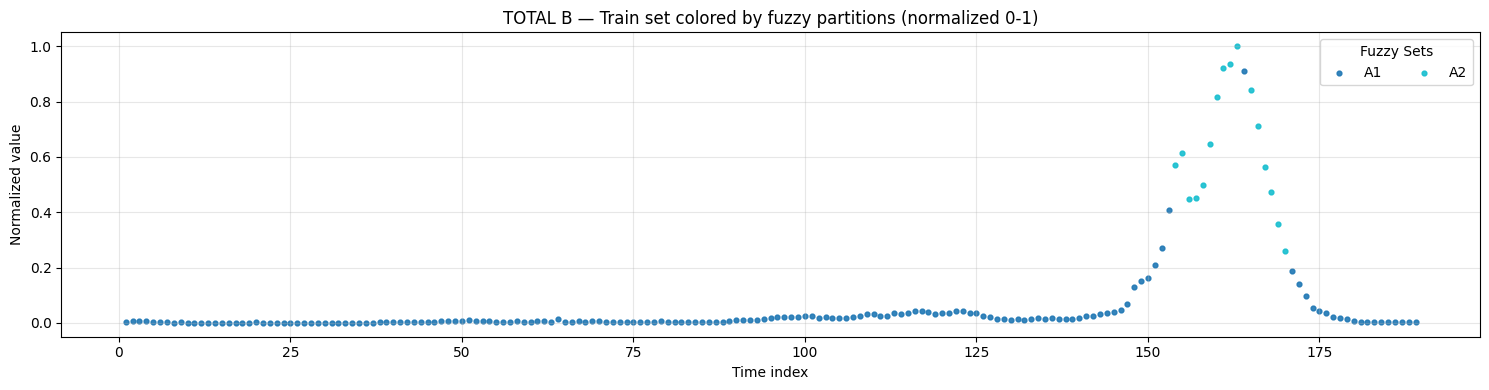

In [ ]:
variables = train_df.columns
time_idx = np.arange(len(train_df))

n_points = fuzzy_X_train.shape[0]  

for v, col in enumerate(variables):
    
    n_clusters = len(fuzzy_sets[col])
    colors = plt.cm.tab10(np.linspace(0, 1, n_clusters))
    
    values = train_df[col].values
    labels_var = fuzzy_X_train[:, v] 
    
    plt.figure(figsize=(15,4))
    
    for lbl in range(n_clusters):
        mask = (labels_var == lbl)
        plt.scatter(
            time_idx[1:1+n_points][mask],  
            values[1:1+n_points][mask],
            color=colors[lbl],
            s=12,
            label=f"A{lbl+1}",
            alpha=0.9
        )
    
    plt.title(f"{col} — Train set colored by fuzzy partitions (normalized 0-1)")
    plt.xlabel("Time index")
    plt.ylabel("Normalized value")
    plt.ylim(-0.05, 1.05)
    plt.legend(title="Fuzzy Sets", loc='upper right', ncol=2)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()



In [ ]:
flrg_var = {col: defaultdict(int) for col in train_df.columns}

for t in range(len(fuzzy_X_train) - 1):
    lhs = tuple(fuzzy_X_train[t]) 
    
    for i, col in enumerate(train_df.columns):
        rhs = fuzzy_Y_train[t][i]   
        flrg_var[col][(lhs, rhs)] += 1

for col in train_df.columns:
    print(f"\nVAR-FTS FLRG — {col} (First-Order, Weighted):")
    for (lhs, rhs), count in sorted(flrg_var[col].items()):
        lhs_str = ",".join([f"A{lbl+1}" for lbl in lhs])
        rhs_str = f"A{rhs+1}"
        print(f"{lhs_str} → {rhs_str} ({count})")



VAR-FTS FLRG — TOTAL SPECIMENS (First-Order, Weighted):
A1,A1,A1 → A1 (132)
A1,A1,A1 → A2 (4)
A1,A1,A2 → A1 (1)
A2,A1,A1 → A1 (2)
A2,A1,A1 → A2 (26)
A2,A1,A2 → A1 (1)
A2,A1,A2 → A2 (12)
A2,A2,A1 → A1 (1)
A2,A2,A1 → A2 (7)
A2,A2,A2 → A2 (2)

VAR-FTS FLRG — TOTAL A (First-Order, Weighted):
A1,A1,A1 → A1 (135)
A1,A1,A1 → A2 (1)
A1,A1,A2 → A1 (1)
A2,A1,A1 → A1 (27)
A2,A1,A1 → A2 (1)
A2,A1,A2 → A1 (12)
A2,A1,A2 → A2 (1)
A2,A2,A1 → A1 (2)
A2,A2,A1 → A2 (6)
A2,A2,A2 → A1 (1)
A2,A2,A2 → A2 (1)

VAR-FTS FLRG — TOTAL B (First-Order, Weighted):
A1,A1,A1 → A1 (136)
A1,A1,A2 → A1 (1)
A2,A1,A1 → A1 (26)
A2,A1,A1 → A2 (2)
A2,A1,A2 → A1 (1)
A2,A1,A2 → A2 (12)
A2,A2,A1 → A1 (8)
A2,A2,A2 → A2 (2)


In [ ]:
order = 2  

flrg_ho_var = {col: defaultdict(int) for col in train_df.columns}

for t in range(order, len(fuzzy_X_train)):
   
    lhs_seq = tuple(tuple(fuzzy_X_train[t - k - 1]) for k in reversed(range(order)))
    
    for i, col in enumerate(train_df.columns):
        rhs = fuzzy_Y_train[t][i]   
        flrg_ho_var[col][(lhs_seq, rhs)] += 1


for col in train_df.columns:
    print(f"\nVAR-FTS High-Order FLRG — {col} (Weighted, order={order}):")
    for (lhs_seq, rhs), count in sorted(flrg_ho_var[col].items()):
        lhs_parts = [" → ".join(",".join(f"A{lbl+1}" for lbl in vec) for vec in lhs_seq)]
        lhs_str = lhs_parts[0]
        rhs_str = f"A{rhs+1}"
        print(f"{lhs_str}  →  {rhs_str} ({count})")



VAR-FTS High-Order FLRG — TOTAL SPECIMENS (Weighted, order=2):
A1,A1,A1 → A1,A1,A1  →  A1 (125)
A1,A1,A1 → A1,A1,A1  →  A2 (6)
A1,A1,A1 → A2,A1,A1  →  A2 (3)
A1,A1,A1 → A2,A2,A1  →  A2 (1)
A1,A1,A2 → A1,A1,A1  →  A1 (1)
A2,A1,A1 → A1,A1,A1  →  A1 (2)
A2,A1,A1 → A2,A1,A1  →  A1 (4)
A2,A1,A1 → A2,A1,A1  →  A2 (19)
A2,A1,A1 → A2,A1,A2  →  A2 (2)
A2,A1,A1 → A2,A2,A1  →  A2 (1)
A2,A1,A2 → A1,A1,A2  →  A1 (1)
A2,A1,A2 → A2,A1,A1  →  A2 (1)
A2,A1,A2 → A2,A1,A2  →  A1 (2)
A2,A1,A2 → A2,A1,A2  →  A2 (8)
A2,A1,A2 → A2,A2,A2  →  A2 (1)
A2,A2,A1 → A1,A1,A1  →  A2 (1)
A2,A2,A1 → A2,A1,A1  →  A2 (1)
A2,A2,A1 → A2,A2,A1  →  A1 (1)
A2,A2,A1 → A2,A2,A1  →  A2 (5)
A2,A2,A2 → A2,A1,A2  →  A2 (1)
A2,A2,A2 → A2,A2,A2  →  A2 (1)

VAR-FTS High-Order FLRG — TOTAL A (Weighted, order=2):
A1,A1,A1 → A1,A1,A1  →  A1 (131)
A1,A1,A1 → A2,A1,A1  →  A1 (3)
A1,A1,A1 → A2,A2,A1  →  A2 (1)
A1,A1,A2 → A1,A1,A1  →  A1 (1)
A2,A1,A1 → A1,A1,A1  →  A1 (2)
A2,A1,A1 → A2,A1,A1  →  A1 (20)
A2,A1,A1 → A2,A1,A1  →  A2 (3)
A2,A1,

In [ ]:
def defuzzify_weighted_var(rhs_dict, fuzzy_sets_var):

    if not rhs_dict:
        return fuzzy_sets_var[len(fuzzy_sets_var)//2][1]

    num = 0.0
    den = 0.0
    for rhs_label, freq in rhs_dict.items():
        _, b, _ = fuzzy_sets_var[rhs_label]  
        num += b * freq
        den += freq
    return num / den


def predict_fofts_var(current_lbl_vec, flrg_var, fuzzy_sets_var_list, target_col):

    rhs_dict = {rhs: count for (lhs, rhs), count in flrg_var[target_col].items() if lhs == tuple(current_lbl_vec)}
    return defuzzify_weighted_var(rhs_dict, fuzzy_sets_var_list[list(train_df.columns).index(target_col)])


def predict_hofts_var(prev_seq_lbl_vecs, flrg_ho_var, fuzzy_sets_var_list, target_col):
    prev_seq_tuple = tuple(
        tuple(vec) if isinstance(vec, (list, np.ndarray)) else vec 
        for vec in prev_seq_lbl_vecs
    )
    
    rhs_dict = {
        rhs: count 
        for (lhs_seq, rhs), count in flrg_ho_var[target_col].items() 
        if lhs_seq == prev_seq_tuple
    }
    return defuzzify_weighted_var(rhs_dict, fuzzy_sets_var_list[list(train_df.columns).index(target_col)])

In [ ]:
def evaluate_model_on_data_var(
    values,                 
    fuzzy_sets_var_list,    
    flrg_var=None,          
    flrg_ho_var=None,       
    order=2,
    model_type='both',
    scaling_params=None     
):

    values = np.array(values, dtype=np.float32)
    n_samples, n_vars = values.shape
    if n_samples <= order:
        return None

    actual = values[order:]
    results = {}

    
    if model_type in ['fofts', 'both']:
        preds_fofts = np.zeros_like(actual)
        for i, col in enumerate(train_df.columns):
            for t in range(order, n_samples):
                lbl_vec = [fuzzify_value(values[t-1, j], fuzzy_sets_var_list[j]) for j in range(n_vars)]
                pred = predict_fofts_var(lbl_vec, flrg_var, fuzzy_sets_var_list, col)

                if scaling_params:
                    pred = pred * (scaling_params[col][1] - scaling_params[col][0]) + scaling_params[col][0]

                preds_fofts[t-order, i] = pred

        mse  = np.mean((actual - preds_fofts)**2, axis=0)
        rmse = np.sqrt(mse)
        mae  = np.mean(np.abs(actual - preds_fofts), axis=0)
        results['fofts'] = {'mse': mse, 'rmse': rmse, 'mae': mae}

    
    if model_type in ['hofts', 'both']:
        preds_hofts = np.zeros_like(actual)
        for i, col in enumerate(train_df.columns):
            for t in range(order, n_samples):
                prev_seq = []
                for k in range(order):
                    lbl_vec = [fuzzify_value(values[t-order+k, j], fuzzy_sets_var_list[j]) for j in range(n_vars)]
                    prev_seq.append(tuple(lbl_vec))

                pred = predict_hofts_var(prev_seq, flrg_ho_var, fuzzy_sets_var_list, col)

                if scaling_params:
                    pred = pred * (scaling_params[col][1] - scaling_params[col][0]) + scaling_params[col][0]

                preds_hofts[t-order, i] = pred

        mse  = np.mean((actual - preds_hofts)**2, axis=0)
        rmse = np.sqrt(mse)
        mae  = np.mean(np.abs(actual - preds_hofts), axis=0)
        results['hofts'] = {'mse': mse, 'rmse': rmse, 'mae': mae}

    return results


In [ ]:
fuzzy_sets_var_list = [fuzzy_sets[col] for col in train_df.columns]  
test_values = Y_test                                  
order = 2 

scaling_params = {col: (df[col].min(), df[col].max()) for col in train_df.columns}

results_test = evaluate_model_on_data_var(
    test_values,
    fuzzy_sets_var_list=fuzzy_sets_var_list,
    flrg_var=flrg_var,
    flrg_ho_var=flrg_ho_var,
    order=order,
    model_type='both',
    scaling_params=scaling_params
)


def print_var_metrics(name, metrics_dict):
    mse = metrics_dict['mse']
    rmse = metrics_dict['rmse']
    mae = metrics_dict['mae']
    
    print(f"{name} (closed-loop VAR-FTS):")
    for i, (m, r, a) in enumerate(zip(mse, rmse, mae), 1):
        line = f" Var{i}: MSE={m:.6f}, RMSE={r:.4f}, MAE={a:.4f}"
        print(line)
    print()


def compute_accuracy(pred_labels, true_labels):
    pred_labels = np.array(pred_labels)
    true_labels = np.array(true_labels)
    if pred_labels.size == 0 or true_labels.size == 0:
        return np.array([0.0] * pred_labels.shape[1])  
    return np.mean(pred_labels == true_labels, axis=0)

def generate_pred_labels_var(test_values, fuzzy_sets_var_list, flrg_var, flrg_ho_var, order=2):
    test_values = np.array(test_values, dtype=np.float32)
    if test_values.ndim == 1:
        test_values = test_values.reshape(-1, len(fuzzy_sets_var_list))
        
    n_samples, n_vars = test_values.shape
    train_labels = list(fuzzy_X_train)
    results = {}

    for key in ['fofts', 'hofts']:
        pred_labels = []

        if key == 'fofts':
            for t in range(n_samples - 1):
                current_lbl_vec = [fuzzify_value(test_values[t, i], fuzzy_sets_var_list[i]) for i in range(n_vars)]
                next_lbl_vec = []
                for i, col in enumerate(train_df.columns):
                    pred = predict_fofts_var(current_lbl_vec, flrg_var, fuzzy_sets_var_list, col)
                    lbl = fuzzify_value(pred, fuzzy_sets_var_list[i])
                    next_lbl_vec.append(lbl)
                pred_labels.append(next_lbl_vec)

        else:
            if len(train_labels) < order:
                raise ValueError("Not enough training labels for high-order prediction.")
            current_seq = train_labels[-order:]
            for t in range(n_samples - 1):
                next_lbl_vec = []
                for i, col in enumerate(train_df.columns):
                    pred = predict_hofts_var(current_seq, flrg_ho_var, fuzzy_sets_var_list, col)
                    lbl = fuzzify_value(pred, fuzzy_sets_var_list[i])
                    next_lbl_vec.append(lbl)
                pred_labels.append(next_lbl_vec)
                current_seq = current_seq[1:] + [next_lbl_vec]

        true_labels = [fuzzify_vector(test_values[t]) for t in range(1, n_samples)]
        results[key] = compute_accuracy(pred_labels, true_labels)

    return results

accuracy_test = generate_pred_labels_var(test_values, fuzzy_sets_var_list, flrg_var, flrg_ho_var, order=order)


if 'fofts' in results_test and results_test['fofts'] is not None:
    print_var_metrics("FOFTS", results_test['fofts'])

if 'hofts' in results_test and results_test['hofts'] is not None:
    print_var_metrics("HOFTS", results_test['hofts'])


for key, acc in accuracy_test.items():
    print(f"{key.upper()} fuzzy label accuracy per variable: {acc}")


if ('fofts' in results_test and results_test['fofts'] is not None) and \
   ('hofts' in results_test and results_test['hofts'] is not None):

    avg_mse_f = np.mean(results_test['fofts']['mse'])
    avg_rmse_f = np.mean(results_test['fofts']['rmse'])
    avg_mae_f = np.mean(results_test['fofts']['mae'])

    avg_mse_h = np.mean(results_test['hofts']['mse'])
    avg_rmse_h = np.mean(results_test['hofts']['rmse'])
    avg_mae_h = np.mean(results_test['hofts']['mae'])

    print("Best algorithm (average over variables):")
    print(f"  MSE   →  {'FOFTS' if avg_mse_f < avg_mse_h else 'HOFTS'}")
    print(f"  RMSE  →  {'FOFTS' if avg_rmse_f < avg_rmse_h else 'HOFTS'}")
    print(f"  MAE   →  {'FOFTS' if avg_mae_f < avg_mae_h else 'HOFTS'}")


FOFTS (closed-loop VAR-FTS):
 Var1: MSE=6867866112.000000, RMSE=82872.5859, MAE=76731.4688
 Var2: MSE=108790512.000000, RMSE=10430.2686, MAE=6538.5151
 Var3: MSE=5161725.000000, RMSE=2271.9431, MAE=1128.1556

HOFTS (closed-loop VAR-FTS):
 Var1: MSE=7134962688.000000, RMSE=84468.7109, MAE=78525.2812
 Var2: MSE=91098808.000000, RMSE=9544.5693, MAE=5461.1929
 Var3: MSE=5612877.000000, RMSE=2369.1511, MAE=1199.1051

FOFTS fuzzy label accuracy per variable: [0.91304348 0.91304348 0.95652174]
HOFTS fuzzy label accuracy per variable: [0.60869565 0.80434783 0.7826087 ]
Best algorithm (average over variables):
  MSE   →  FOFTS
  RMSE  →  FOFTS
  MAE   →  FOFTS


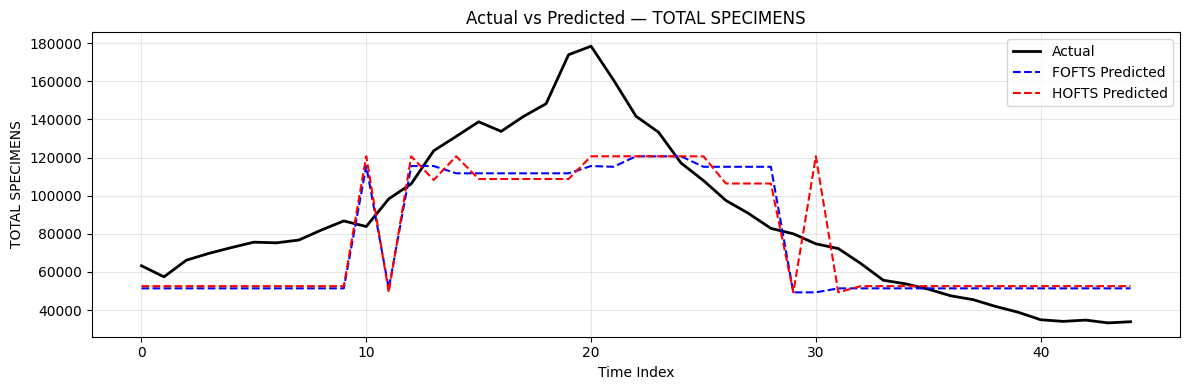

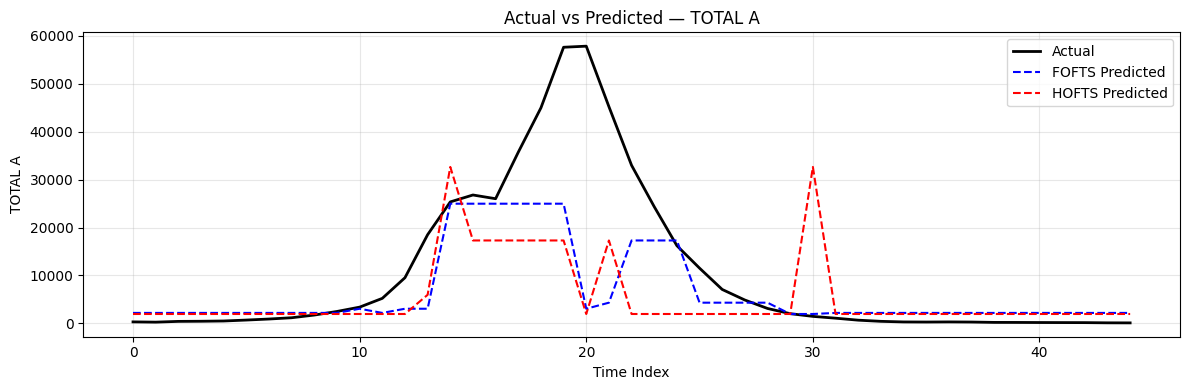

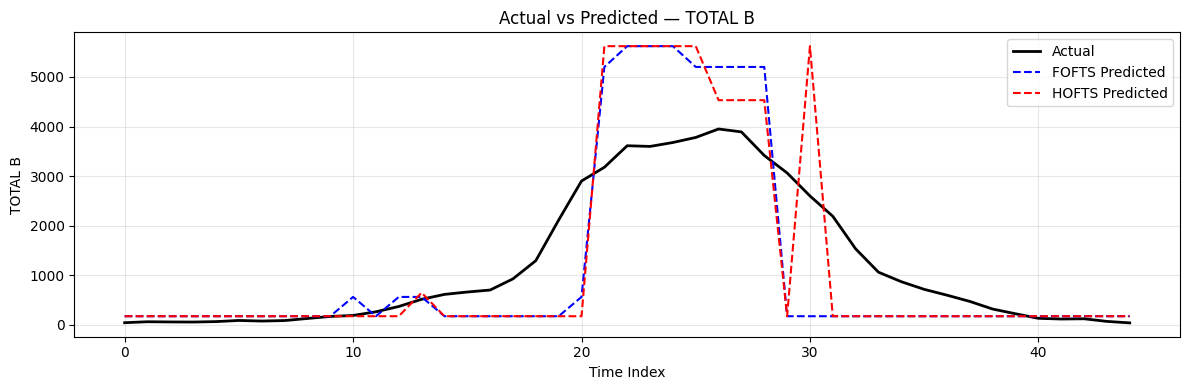

In [ ]:
def plot_actual_vs_pred(test_values, fuzzy_sets_var_list, flrg_var, flrg_ho_var, order=2, scaling_params=None):
    test_values = np.array(test_values, dtype=np.float32)
    n_samples, n_vars = test_values.shape
    
    preds = {'FOFTS': np.zeros((n_samples-order, n_vars)),
             'HOFTS': np.zeros((n_samples-order, n_vars))}
    
    for i, col in enumerate(train_df.columns):
        for t in range(order, n_samples):
            lbl_vec = [fuzzify_value(test_values[t-1, j], fuzzy_sets_var_list[j]) for j in range(n_vars)]
            pred_fo = predict_fofts_var(lbl_vec, flrg_var, fuzzy_sets_var_list, col)
            prev_seq = [tuple([fuzzify_value(test_values[t-order+k, j], fuzzy_sets_var_list[j]) for j in range(n_vars)])
                        for k in range(order)]
            pred_ho = predict_hofts_var(prev_seq, flrg_ho_var, fuzzy_sets_var_list, col)
            
            if scaling_params:
                pred_fo = pred_fo * (scaling_params[col][1] - scaling_params[col][0]) + scaling_params[col][0]
                pred_ho = pred_ho * (scaling_params[col][1] - scaling_params[col][0]) + scaling_params[col][0]
            
            preds['FOFTS'][t-order, i] = pred_fo
            preds['HOFTS'][t-order, i] = pred_ho
    
    actual_scaled = np.zeros_like(preds['FOFTS'])
    for i, col in enumerate(train_df.columns):
        if scaling_params:
            actual_scaled[:, i] = test_values[order:, i] * (scaling_params[col][1] - scaling_params[col][0]) + scaling_params[col][0]
        else:
            actual_scaled[:, i] = test_values[order:, i]
    
    time_idx = np.arange(len(actual_scaled))
    
    for i, col in enumerate(train_df.columns):
        plt.figure(figsize=(12,4))
        plt.plot(time_idx, actual_scaled[:, i], label='Actual', color='black', linewidth=2)
        plt.plot(time_idx, preds['FOFTS'][:, i], label='FOFTS Predicted', color='blue', linestyle='--')
        plt.plot(time_idx, preds['HOFTS'][:, i], label='HOFTS Predicted', color='red', linestyle='--')
        plt.title(f"Actual vs Predicted — {col}")
        plt.xlabel("Time Index")
        plt.ylabel(col)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()


plot_actual_vs_pred(test_values, fuzzy_sets_var_list, flrg_var, flrg_ho_var, order=order, scaling_params=scaling_params)
